# Mini project - 택시 이용내역 데이터

In [209]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as datetime

import statsmodels.formula.api as smf
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic'  # 기본 폰트 설정 (macOS)
plt.rcParams['axes.unicode_minus'] = False 

In [210]:
data = pd.read_csv('trip.csv')

## 1. Trip Data 정보 탐색

### 1-1. 결측치 확인 및 변수 설명

In [211]:
print(data.info())
print(data.isnull().any()) #결측치 확인
display(data.head())
print(data['payment_method'].value_counts())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22701 entries, 0 to 22700
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   passenger_name         22701 non-null  object 
 1   tpep_pickup_datetime   22701 non-null  object 
 2   tpep_dropoff_datetime  22701 non-null  object 
 3   payment_method         22701 non-null  object 
 4   passenger_count        22701 non-null  int64  
 5   trip_distance          22701 non-null  float64
 6   fare_amount            22698 non-null  float64
 7   tip_amount             22701 non-null  float64
 8   tolls_amount           22701 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 1.6+ MB
None
passenger_name           False
tpep_pickup_datetime     False
tpep_dropoff_datetime    False
payment_method           False
passenger_count          False
trip_distance            False
fare_amount               True
tip_amount               False
tolls

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
0,Pamela Duffy,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,Debit Card,6,3.34,13.0,2.76,0.0
1,Michelle Foster,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,Debit Card,1,1.80,16.0,4.00,0.0
2,Tina Combs,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,Debit Card,1,1.00,6.5,1.45,0.0
3,Anthony Ray,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,Cash,1,3.70,20.5,6.39,0.0
4,Brianna Johnson,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,Debit Card,1,4.37,16.5,0.00,0.0


payment_method
Cash           11196
Debit Card      5783
Credit Card     5722
Name: count, dtype: int64
       passenger_count  trip_distance   fare_amount    tip_amount  \
count     22701.000000   22701.000000  22698.000000  22701.000000   
mean          1.643584       2.913400     13.024009      1.835745   
std           1.304942       3.653023     13.240074      2.800537   
min           0.000000       0.000000   -120.000000      0.000000   
25%           1.000000       0.990000      6.500000      0.000000   
50%           1.000000       1.610000      9.500000      1.350000   
75%           2.000000       3.060000     14.500000      2.450000   
max          36.000000      33.960000    999.990000    200.000000   

       tolls_amount  
count  22701.000000  
mean       0.312514  
std        1.399153  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        0.000000  
max       19.100000  


In [212]:
#톨게이트 비용 낸 사람 - 1173명
print(data[data['tolls_amount']>0].value_counts().sum())
#팁 낸사람 - 14640명
print(data[data['tip_amount']>0].value_counts().sum())
#0명 탄사람? 이건 뭐야
print(data[data['passenger_count']==0].value_counts().sum())

1173
14641
33


데이터 정보 

passenger_name 
- str 고객 이름

datetime 모듈
tpep_pickup_datetime & tpep_dropoff_datetime 
- 날짜,시간 변수 고객을 태운 시간 내려준 시간  

payment_method 
- 결제방법 (현금(11196명), 체크카드(5783명), 신용카드(5722명))


passenger_count 
- 승객 수

trip_distance 
- 태운 거리

fare_amount 
- min -120 이거 뭔가 의심됨 max값도 999.999..?(이상치 제거 필요)
- 요금

tip_amount
- 팁도 max가 200인거 보면 좀 의심됨(이상치 제거 필요)
- 팁 낸 사람은 14000명 정도

tolls_amount 
- 75분위수까진 다 0인데 max만 19.1 (의심)
- 톨게이트 비용




In [213]:
print(data[data['fare_amount'].isna()])

       passenger_name    tpep_pickup_datetime  tpep_dropoff_datetime  \
52   Benjamin Johnson   04/04/2017 4:22:03 PM  04/04/2017 4:35:30 PM   
189      Maria Ibarra  08/21/2017 12:40:25 PM  08/21/2017 1:12:31 PM   
244        Tina Avila   08/09/2017 8:32:09 AM  08/09/2017 9:31:11 AM   

    payment_method  passenger_count  trip_distance  fare_amount  tip_amount  \
52            Cash                1           2.20          NaN         0.0   
189     Debit Card                3          15.20          NaN         5.0   
244           Cash                1          15.89          NaN        10.0   

     tolls_amount  
52           0.00  
189          0.00  
244          5.76  


데이터가 pure 하다 볼 수는 없음!

결측치 확인 :  fare_amount 에 결측치 있음 (3개)
index : #52,#189,#244 

In [251]:
#팁 + 요금 + 톨비 = 총 요금
data.dropna()

data['total_fare'] = data['fare_amount'] + data['tip_amount'] + data['tolls_amount']

#이동 시간(분)
data['tpep_pickup_datetime'] = pd.to_datetime(data['tpep_pickup_datetime'])
data['tpep_dropoff_datetime'] = pd.to_datetime(data['tpep_dropoff_datetime'])
data['taxi_time']= data['tpep_dropoff_datetime'] - data['tpep_pickup_datetime']
data['taxi_time_min'] = data['taxi_time'].dt.total_seconds() / 60

#카드 + 현금으로 바꾸기
data['payment_method'] = data['payment_method'].replace({
    'Credit Card': 'Card', 
    'Debit Card': 'Card'
})

### IQR 기반 이상치 제거 

팁이 0인게 많다 -> 팁은 내는 사람들만 낸다!  

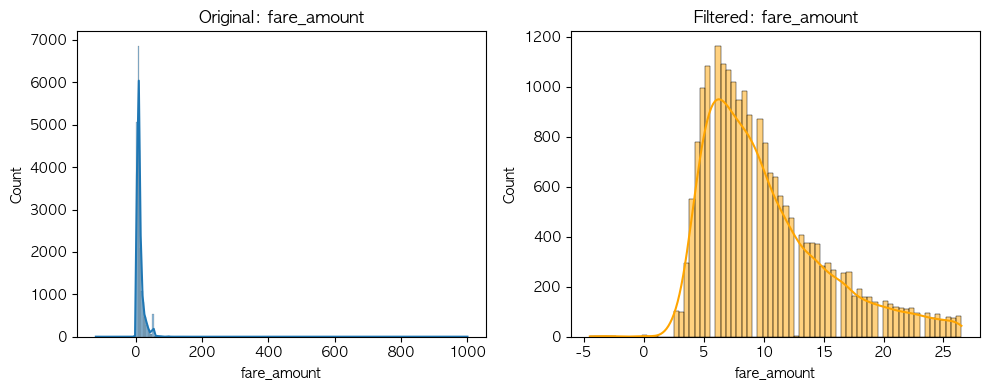

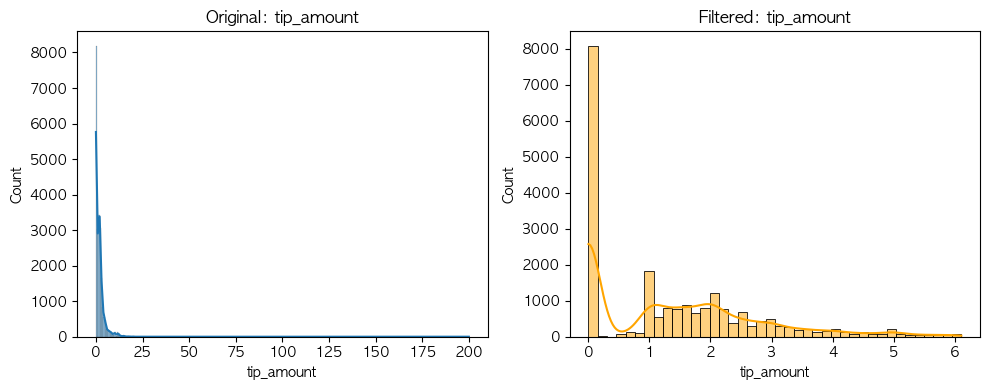

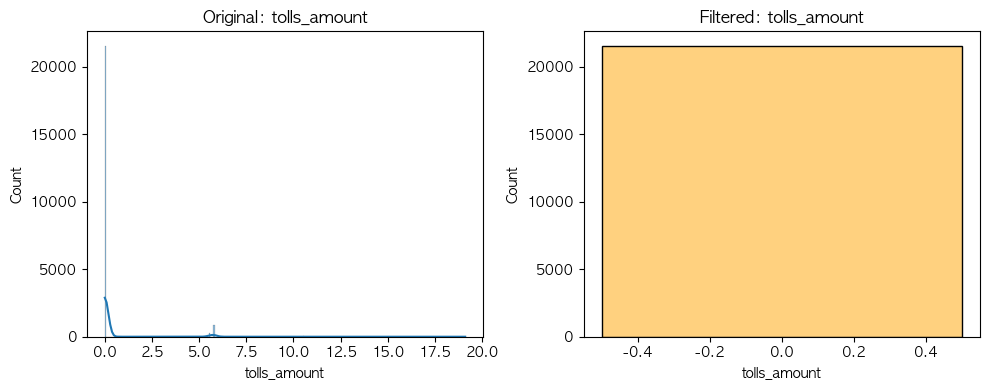

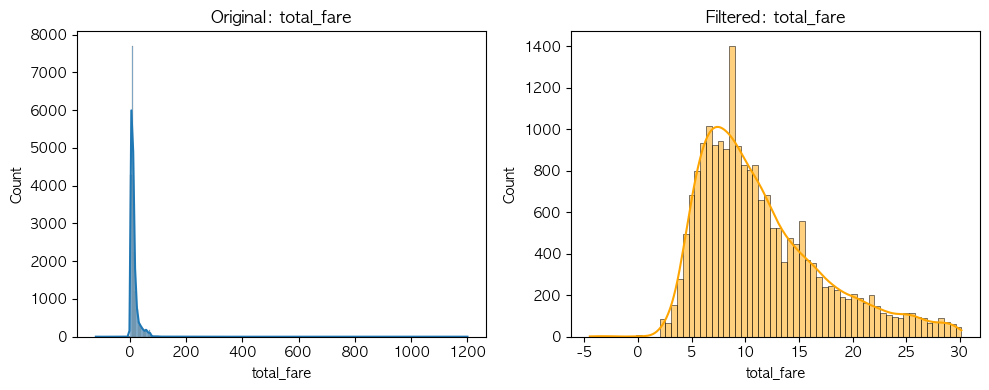

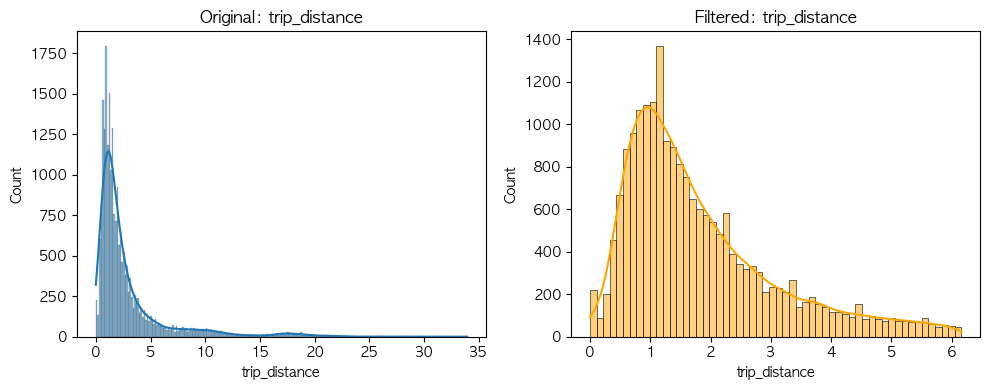

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,total_fare,taxi_time,taxi_time_min
0,Pamela Duffy,2017-03-25 08:55:43,2017-03-25 09:09:47,Card,6,3.34,13.0,2.76,0.0,15.76,0 days 00:14:04,14.066667
1,Michelle Foster,2017-04-11 14:53:28,2017-04-11 15:19:58,Card,1,1.80,16.0,4.00,0.0,20.00,0 days 00:26:30,26.500000
2,Tina Combs,2017-12-15 07:26:56,2017-12-15 07:34:08,Card,1,1.00,6.5,1.45,0.0,7.95,0 days 00:07:12,7.200000
3,Anthony Ray,2017-05-07 13:17:59,2017-05-07 13:48:14,Cash,1,3.70,20.5,6.39,0.0,26.89,0 days 00:30:15,30.250000
4,Brianna Johnson,2017-04-15 23:32:20,2017-04-15 23:49:03,Card,1,4.37,16.5,0.00,0.0,16.50,0 days 00:16:43,16.716667
...,...,...,...,...,...,...,...,...,...,...,...,...
22695,Patrick Williams,2017-08-10 22:20:04,2017-08-10 22:29:31,Cash,1,0.89,7.5,1.76,0.0,9.26,0 days 00:09:27,9.450000
22696,Austin Johnson,2017-02-24 17:37:23,2017-02-24 17:40:39,Cash,3,0.61,4.0,0.00,0.0,4.00,0 days 00:03:16,3.266667
22698,Drew Graves,2017-09-04 14:54:14,2017-09-04 14:58:22,Card,1,0.42,4.5,0.00,0.0,4.50,0 days 00:04:08,4.133333
22699,Jonathan Copeland,2017-07-15 12:56:30,2017-07-15 13:08:26,Card,1,2.36,10.5,1.70,0.0,12.20,0 days 00:11:56,11.933333


In [256]:
#반복문으로 수치형 변수들 이상치 제거

filtered_data = data.copy()
feature = ['fare_amount','tip_amount','tolls_amount','total_fare','trip_distance']


for col in feature:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    filtered_data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)
                        ]
    
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    sns.histplot(data[col], kde=True)
    plt.title(f'Original: {col}')
    
    plt.subplot(1, 2, 2)
    sns.histplot(filtered_data[col], kde=True, color='orange')
    plt.title(f'Filtered: {col}')
    
    plt.tight_layout()
    plt.show()
    
filtered_data.dropna()

'tolls_amount' 는 IQR기반 이상치를 제거하니 이쁘게 나오지 않았다.

결측값 3개의 데이터도 filtered_data과정에서 없어짐.

'tip_amount' 는 0값이 많아서 제거하고 한번 더 해야겠다고 생각

근데 이제 팁을 제외한 금액을 새로 파생변수를 만듦 -> 그럼 팁이 0 인 고객을 크게 생각 안해도 될 것 같음

### 총 이동시간(분) vs 팁을 제외한 요금 사이의 산점도

이동시간이 1000분 이상인 고객은 이상치로 판단 후 데이터 필터링과정에서 제거함. + 80분쯤에 0원 낸 고객도

미터기를 켜놓고 끄지 않고 그대로 주행시간에 포함되어 그런 것 같음(예상)

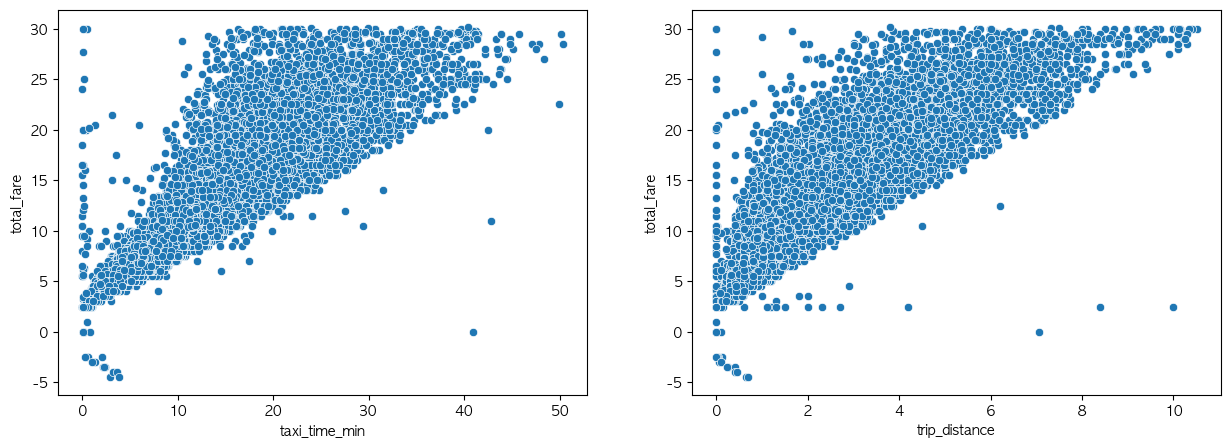

In [257]:
#이동시간인 taxi_time_min 변수 사용
data['taxi_time_min'] = data['taxi_time'].dt.total_seconds() /60
data['total_fare'] = data['fare_amount'] + data['tip_amount'] + data['tolls_amount']

Q1 = data['total_fare'].quantile(0.25)
Q3 = data['total_fare'].quantile(0.75)
IQR = Q3 - Q1
    
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

filtered_fare = data[(data['total_fare'] >= lower_bound) & (data['total_fare'] <= upper_bound)
                    &(data['taxi_time_min']<80) &(data['taxi_time_min']>=0)]

plt.figure(figsize=(15, 5))
plt.subplot(1,2,1)
sns.scatterplot(data=filtered_fare,x='taxi_time_min',y='total_fare')
plt.subplot(1,2,2)
sns.scatterplot(data=filtered_fare,x='trip_distance',y='total_fare')
plt.show()

해석
- 시간이 지남에 따라 요금의 변동폭이 커지는 편 (할증이 있는 것 같음)&(이분산성 관찰됨)

- 이상치를 제외한 고객들은 보통 1시간 이내의 거리이동에 택시를 이용함

### 상관계수 분석

<Axes: >

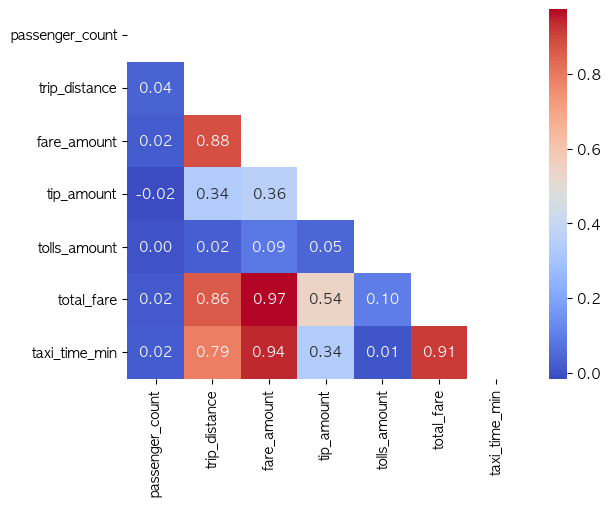

In [258]:
#이분산성이라 순위기반 스피어맨 상관계수 써봄
numeric_df_corr = filtered_data.corr(numeric_only=True,method='spearman') 
mask = np.triu(np.ones_like(numeric_df_corr, dtype=bool))
sns.heatmap(numeric_df_corr,mask=mask,annot=True,fmt='.2f',cmap='coolwarm')

#### 해석

이상치 제거 후 상관계수 히트맵을 구성. (이동거리 & 이동시간) vs 총 요금 간의 강한 선형결합 

### 총 요금 ~ 거리 의 단순선형회귀

In [ ]:
filtered_data = filtered_data.dropna()
model1 = smf.ols(formula='total_fare ~ trip_distance + taxi_time_min', data=filtered_data).fit()
print(model1.summary())


y = filtered_data['payment_method'].map({'Card':1 , 'Cash':0})
X = filtered_data[]
X_const = sm.add_constant(X)

model2 = sm.Logit(y,X_const).fit()
print(model2.summary())



                            OLS Regression Results                            
Dep. Variable:             total_fare   R-squared:                       0.162
Model:                            OLS   Adj. R-squared:                  0.162
Method:                 Least Squares   F-statistic:                     1944.
Date:                Thu, 05 Feb 2026   Prob (F-statistic):               0.00
Time:                        16:45:46   Log-Likelihood:                -75686.
No. Observations:               20173   AIC:                         1.514e+05
Df Residuals:                   20170   BIC:                         1.514e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         4.8983      0.128     38.305